# MGT 209 Exercise — Toothpaste Consumer Segmentation

**Course:** MGT 209: Marketing Management  
**Session:** Data-based Segmentation and Targeting  
**Exercise:** Segmenting Markets for Toothpaste  
**Dataset:** `cluster_toothpaste.csv`

## Exercise Background

The Session 005 introduces **data-based segmentation** and **K-means clustering**. The course describes K-means as an iterative procedure in which each cluster has a centroid, each observation is assigned to its closest centroid, and distance is measured using **Euclidean distance**.

Exercise **“Segmenting Markets for Toothpaste.”** has an accompanying course dataset contains 60 consumers and six toothpaste-related rating dimensions:

- `Anti.Cavity`
- `Whiten.Teeth`
- `Gum.Strengthen`
- `Fresh.Breath`
- `Tooth.Decay`
- `Fill.Tooth.Gaps`

### Analytical objective

Use the six course-provided variables to identify groups of consumers with similar toothpaste-related response patterns, profile the resulting clusters, and connect the exercise to the course's segmentation logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_rows", 70)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

DATA_PATH = "/mnt/data/cluster_toothpaste.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(10))


Shape: (60, 7)
Columns: ['consumer', 'Anti.Cavity', 'Whiten.Teeth', 'Gum.Strengthen', 'Fresh.Breath', 'Tooth.Decay', 'Fill.Tooth.Gaps']


,consumer,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps
0,1,7,3,6,4,2,4
1,2,1,3,2,4,5,4
2,3,6,2,7,4,1,3
3,4,4,5,4,6,2,5
4,5,1,2,2,3,6,2
5,6,6,3,6,4,2,4
6,7,5,3,6,3,4,3
7,8,6,4,7,4,1,4
8,10,2,6,2,6,7,6
9,11,6,4,7,3,2,3


## 1. Data Inspection

`consumer` is an identifier and is **not** used to calculate distances.

The remaining six columns are the segmenting variables. All six are measured on the same observed 1–7 numerical range in this dataset, so no rescaling is applied in this reproduction.


In [2]:
features = [
    "Anti.Cavity",
    "Whiten.Teeth",
    "Gum.Strengthen",
    "Fresh.Breath",
    "Tooth.Decay",
    "Fill.Tooth.Gaps"
]

print("Missing values:")
display(df[features].isna().sum().to_frame("Missing"))

print("\nDescriptive statistics:")
display(df[features].describe().T)


Missing values:


,Missing
Anti.Cavity,0
Whiten.Teeth,0
Gum.Strengthen,0
Fresh.Breath,0
Tooth.Decay,0
Fill.Tooth.Gaps,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Anti.Cavity,60.000,3.933,1.965,1.000,2.000,4.000,6.000,7.000
Whiten.Teeth,60.000,3.900,1.362,2.000,3.000,4.000,5.000,7.000
Gum.Strengthen,60.000,4.100,2.039,1.000,2.000,4.000,6.000,7.000
Fresh.Breath,60.000,4.100,1.362,2.000,3.000,4.000,5.000,7.000
Tooth.Decay,60.000,3.500,1.891,1.000,2.000,3.500,5.000,7.000
Fill.Tooth.Gaps,60.000,4.167,1.380,2.000,3.000,4.000,5.000,7.000


## 2. Inspect the Six-Dimensional Response Patterns

Cluster analysis is useful when observations need to be grouped on **multiple characteristics**. Here, the six variables jointly define each consumer's toothpaste-related response profile.

A correlation matrix provides a compact first look at how the dimensions move together. It is descriptive only and does not determine the clusters.


,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps
Anti.Cavity,1.000,-0.053,0.873,-0.086,-0.858,0.004
Whiten.Teeth,-0.053,1.000,-0.155,0.572,0.020,0.640
Gum.Strengthen,0.873,-0.155,1.000,-0.248,-0.778,-0.018
Fresh.Breath,-0.086,0.572,-0.248,1.000,-0.007,0.640
Tooth.Decay,-0.858,0.020,-0.778,-0.007,1.000,-0.136
Fill.Tooth.Gaps,0.004,0.640,-0.018,0.640,-0.136,1.000


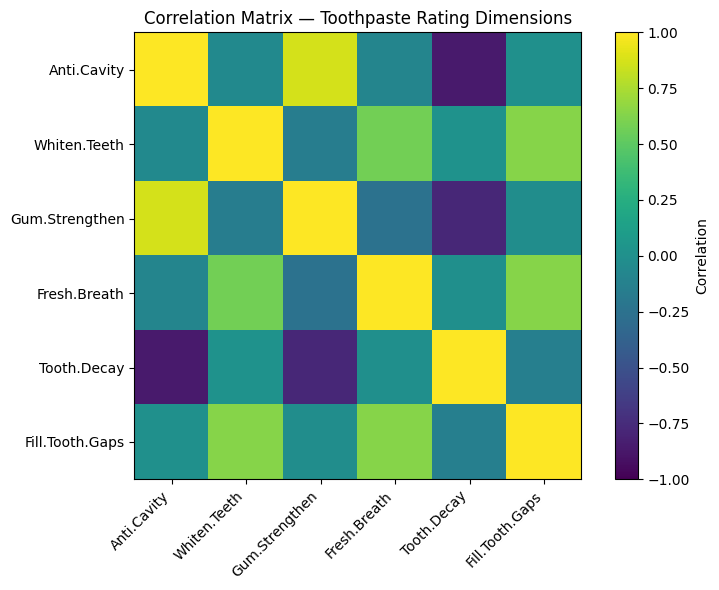

In [3]:
corr = df[features].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)
ax.set_title("Correlation Matrix — Toothpaste Rating Dimensions")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


## 3. Select K for This Reproduction

Compares candidate solutions from **K = 2 to K = 7**.

Two diagnostics are reported:

- **Inertia / within-cluster sum of squares:** decreases as clusters become more compact.
- **Silhouette score:** higher values indicate better separation and cohesion for a given solution.

In [4]:
X = df[features].copy()

diagnostics = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=209, n_init=50)
    labels = model.fit_predict(X)
    diagnostics.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X, labels)
    })

diagnostics_df = pd.DataFrame(diagnostics)
display(diagnostics_df)

best_k = int(diagnostics_df.loc[diagnostics_df["Silhouette"].idxmax(), "K"])
print("Highest silhouette score occurs at K =", best_k)


,K,Inertia,Silhouette
0,2,496.833,0.463
1,3,249.816,0.547
2,4,207.983,0.529
3,5,172.540,0.430
4,6,149.143,0.368
5,7,129.095,0.409


Highest silhouette score occurs at K = 3


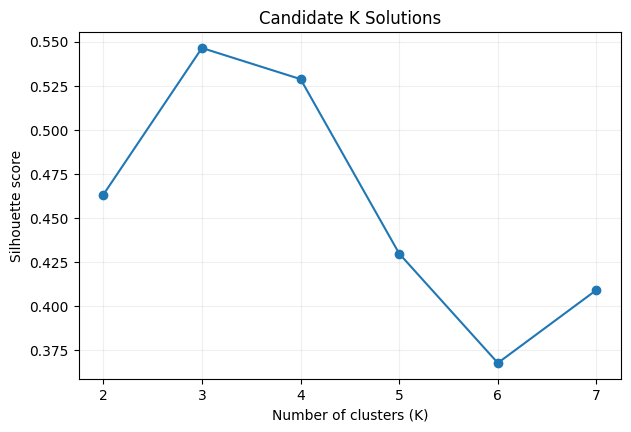

In [5]:
plt.figure(figsize=(7, 4.5))
plt.plot(diagnostics_df["K"], diagnostics_df["Silhouette"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Candidate K Solutions")
plt.xticks(diagnostics_df["K"])
plt.grid(alpha=0.2)
plt.show()


## 4. K-means Clustering

Based on the diagnostic comparison above, this reproduction uses **K = 3**.

Because all six clustering variables use the same observed 1–7 scale, K-means is applied directly to the original values. A fixed random seed and multiple initializations make the result reproducible.


In [6]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=209, n_init=50)
raw_labels = kmeans.fit_predict(X)

df_result = df.copy()
df_result["Cluster"] = raw_labels + 1

print("Iterations to convergence:", kmeans.n_iter_)
print("Within-cluster sum of squares (inertia):", round(kmeans.inertia_, 3))
print("Silhouette score:", round(silhouette_score(X, raw_labels), 3))

display(df_result.head(15))


Iterations to convergence: 2
Within-cluster sum of squares (inertia): 249.816
Silhouette score: 0.547


,consumer,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps,Cluster
0,1,7,3,6,4,2,4,1
1,2,1,3,2,4,5,4,2
2,3,6,2,7,4,1,3,1
3,4,4,5,4,6,2,5,3
4,5,1,2,2,3,6,2,2
5,6,6,3,6,4,2,4,1
6,7,5,3,6,3,4,3,1
7,8,6,4,7,4,1,4,1
8,10,2,6,2,6,7,6,3
9,11,6,4,7,3,2,3,1


## 5. Cluster Sizes and Centroids

The centroid is the average six-dimensional response profile of the consumers assigned to a cluster.

Cluster numbers are arbitrary algorithmic labels. They do **not** represent an ordering from best to worst.


In [7]:
cluster_sizes = (
    df_result["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Consumers")
)

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features,
    index=[f"Cluster {i}" for i in range(1, K + 1)]
)

print("Cluster sizes:")
display(cluster_sizes.to_frame())

print("\nCluster centroids:")
display(centroids)


Cluster sizes:


,Consumers
Cluster,
1,26
2,18
3,16



Cluster centroids:


,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps
Cluster 1,5.846,3.385,6.154,3.385,1.923,3.769
Cluster 2,1.667,3.000,1.889,3.444,5.556,3.222
Cluster 3,3.375,5.750,3.250,6.000,3.750,5.875


## 6. Profile the Consumer Segments

The centroid profiles show which toothpaste-related dimensions are relatively higher or lower within each cluster. The interpretation below remains descriptive rather than treating high values as a specific construct such as “importance.”

In [8]:
overall_mean = df[features].mean()
relative_profiles = centroids.subtract(overall_mean, axis=1)

print("Centroid minus overall sample mean:")
display(relative_profiles)

profile_summary = []
for i in range(1, K + 1):
    row = relative_profiles.loc[f"Cluster {i}"]
    profile_summary.append({
        "Cluster": i,
        "Consumers": int(cluster_sizes.loc[i]),
        "Share": cluster_sizes.loc[i] / len(df),
        "Relatively Higher Dimensions": ", ".join(row.sort_values(ascending=False).head(2).index),
        "Relatively Lower Dimensions": ", ".join(row.sort_values().head(2).index)
    })

profile_summary = pd.DataFrame(profile_summary)
display(profile_summary)


Centroid minus overall sample mean:


,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps
Cluster 1,1.913,-0.515,2.054,-0.715,-1.577,-0.397
Cluster 2,-2.267,-0.900,-2.211,-0.656,2.056,-0.944
Cluster 3,-0.558,1.850,-0.850,1.900,0.250,1.708


,Cluster,Consumers,Share,Relatively Higher Dimensions,Relatively Lower Dimensions
0,1,26,0.433,"Gum.Strengthen, Anti.Cavity","Tooth.Decay, Fresh.Breath"
1,2,18,0.300,"Tooth.Decay, Fresh.Breath","Anti.Cavity, Gum.Strengthen"
2,3,16,0.267,"Fresh.Breath, Whiten.Teeth","Gum.Strengthen, Anti.Cavity"


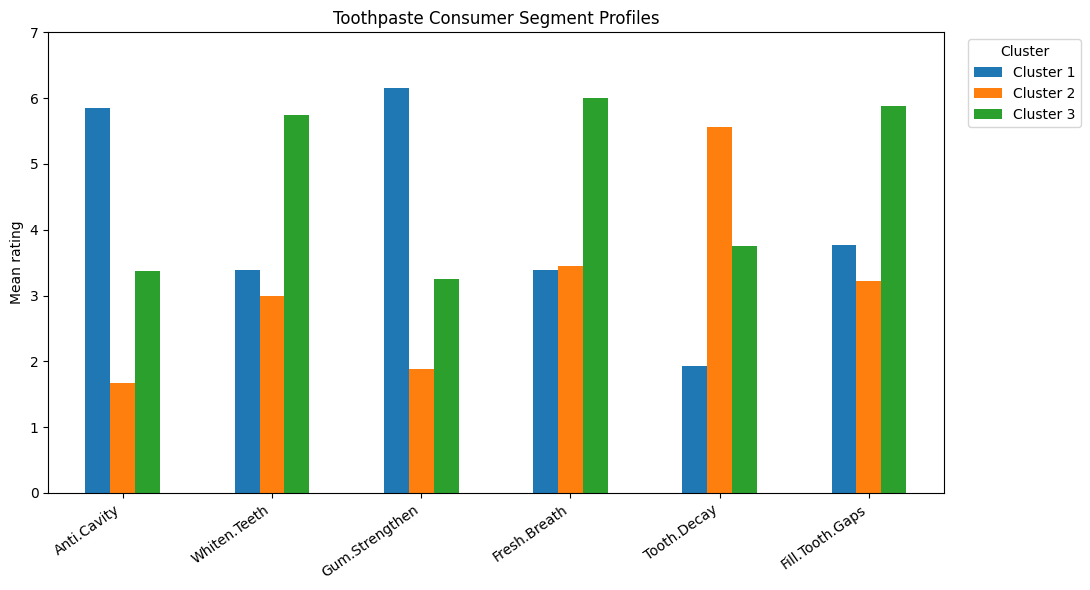

In [9]:
ax = centroids.T.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Mean rating")
ax.set_title("Toothpaste Consumer Segment Profiles")
ax.set_ylim(0, 7)
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 7. Consumer-Level Cluster Assignments

The table below preserves each consumer's six original responses and adds the final cluster assignment.


In [10]:
assignments = df_result[["consumer"] + features + ["Cluster"]].sort_values("consumer")
display(assignments)


,consumer,Anti.Cavity,Whiten.Teeth,Gum.Strengthen,Fresh.Breath,Tooth.Decay,Fill.Tooth.Gaps,Cluster
0,1,7,3,6,4,2,4,1
1,2,1,3,2,4,5,4,2
2,3,6,2,7,4,1,3,1
3,4,4,5,4,6,2,5,3
4,5,1,2,2,3,6,2,2
5,6,6,3,6,4,2,4,1
6,7,5,3,6,3,4,3,1
7,8,6,4,7,4,1,4,1
34,9,3,4,2,3,6,3,2
8,10,2,6,2,6,7,6,3


## 8. Two-Dimensional Visualization with PCA

The K-means solution uses **all six original variables**. PCA is used only to display the six-dimensional observations in two dimensions; PCA does not create the clusters in this notebook.


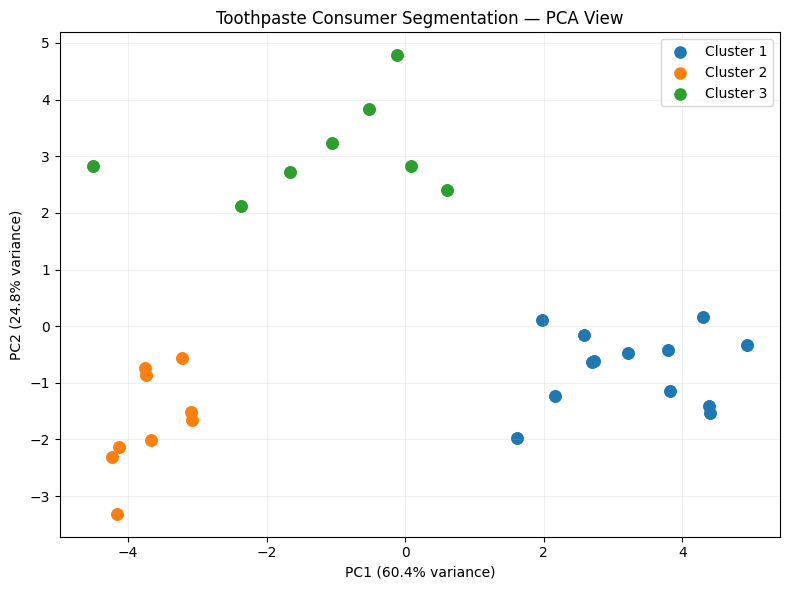

Variance represented by the two plotted components: 85.2%


In [11]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "Cluster": df_result["Cluster"],
    "Consumer": df_result["consumer"]
})

plt.figure(figsize=(8, 6))
for cluster, group in plot_df.groupby("Cluster"):
    plt.scatter(group["PC1"], group["PC2"], s=65, label=f"Cluster {cluster}")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Toothpaste Consumer Segmentation — PCA View")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print("Variance represented by the two plotted components:",
      f"{pca.explained_variance_ratio_.sum():.1%}")


## 9. Euclidean-Distance Verification

The course K-means logic assigns each observation to its closest centroid using **Euclidean distance**:

d(x,c)=sqrt{sum_j (x_j-c_j)^2}

The following calculation verifies the final assignment for every consumer across all six dimensions.


In [12]:
centers = kmeans.cluster_centers_
distances = np.sqrt(((X.to_numpy()[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2))

distance_df = pd.DataFrame(
    distances,
    columns=[f"Distance to Cluster {i}" for i in range(1, K + 1)]
)

verification = pd.concat(
    [df_result[["consumer", "Cluster"]].reset_index(drop=True), distance_df],
    axis=1
)
verification["Nearest Cluster"] = distances.argmin(axis=1) + 1
verification["Assignment Verified"] = verification["Cluster"] == verification["Nearest Cluster"]

display(verification.head(15))
print("All consumers assigned to their nearest final centroid:",
      verification["Assignment Verified"].all())


,consumer,Cluster,Distance to Cluster 1,Distance to Cluster 2,Distance to Cluster 3,Nearest Cluster,Assignment Verified
0,1,1,1.393,7.675,6.232,1,True
1,2,2,7.126,1.296,4.883,2,True
2,3,1,2.116,8.186,7.406,1,True
3,4,3,4.361,6.020,2.312,3,True
4,5,2,7.909,1.829,7.095,2,True
5,6,1,0.796,7.017,5.709,1,True
6,7,1,2.437,5.539,5.924,1,True
7,8,1,1.550,8.220,6.252,1,True
8,10,3,8.745,5.045,3.754,3,True
9,11,1,1.365,7.667,6.659,1,True


All consumers assigned to their nearest final centroid: True


## 10. Marketing Interpretation

This exercise demonstrates the **data-based segmentation** logic: consumers are grouped according to similarities across multiple observed variables rather than being divided using a single demographic or predefined category.

The resulting clusters provide distinct multivariate profiles that could be used as a starting point for further segmentation work. However, clustering alone does **not** establish which segment should be targeted. Targeting would require additional information about segment size, market attractiveness, accessibility, company objectives, and resources.

We should also aution that no clustering algorithm can prove that it has found the single best solution. A useful segmentation should ultimately be interpretable and relevant to the marketing decision.


## 11. Exercise Takeaways

1. K-means as a **data-based segmentation** method.
2. Consumers are compared simultaneously across six toothpaste-related rating dimensions.
3. K-means uses **centroids** and **Euclidean distance** to assign observations to clusters.
4. Evaluates candidate K values and uses **K = 3**, the strongest silhouette solution among K = 2–7.
5. All six variables share the same observed 1–7 scale, so no standardization is applied.
6. Cluster profiles describe how groups differ; they do not by themselves determine which segment should be targeted.

### Source / Provenance

Course-provided instructional dataset `cluster_toothpaste.csv`, associated with the **Segmenting Markets for Toothpaste”** exercise in **MGT 209: Marketing Management**, Session 005 — **Data-based Segmentation and Targeting**, UC Riverside, Winter 2023.